In [ ]:
%matplotlib inline
# tag: remove-cell applied

# Continuous Data with Bayesian Model Averaging

## Table of Contents

- [Single model fit - LOUD](#single-model-fit---loud)
- [Multiple model fit (sessions) - LOUD](#multiple-model-fit-sessions---LOUD)
- [Running expanded suite analyses](#running-expanded-suite-analyses)

Bayesian model averaging is currently available for continuous datasets in `pybmds`using the Bayesian LOUD 
(Leveraging Objective Univariate Distributions) method.  Here, we describe how to run a continuous 
analysis using a single model, or model averaging using the standard BMDS suite of models or the expanded suite using PROAST or EFSA models.  Additionally, we demonstrate how to plot your results. 

## Single model fit - LOUD

You can run individual models using the Bayesian LOUD approach rather than running all models and finding the model average.

To run the Exponential 5 model: 

     Exponential 5 Model      
══════════════════════════════

Version: pybmds 25.2 (bmdscore 25.2)

Input Summary:
╒══════════════════════════════╤════════════════════════════╕
│ BMR                          │ 1.0 Standard Deviation     │
│ Distribution                 │ Normal + Constant variance │
│ Modeling Direction           │ Up (↑)                     │
│ Confidence Level (one sided) │ 0.95                       │
│ Modeling Approach            │ Bayesian                   │
╘══════════════════════════════╧════════════════════════════╛

Parameter Settings:
╒═════════════╤════════════════╤════════════════════════════════════════════════════════════╕
│ Parameter   │ Distribution   │ Definition                                                 │
╞═════════════╪════════════════╪════════════════════════════════════════════════════════════╡
│ m0          │ Student_t      │ df=19.0, loc=6.0, scale=0.917662935482247                  │
│ m1          │ Student_t      │ df=19.0, loc=30.0, s

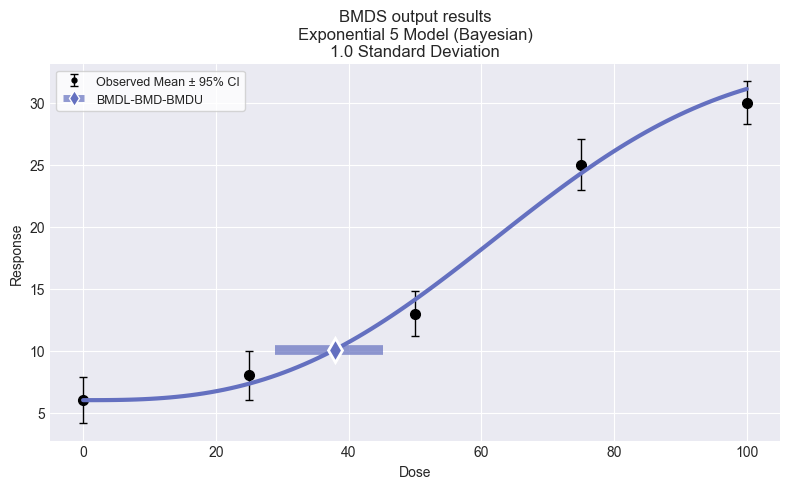

In [1]:
import pybmds
from pybmds.models import continuous

# create a continuous dataset
dataset = pybmds.ContinuousDataset(
    doses=[0, 25, 50, 75, 100],
    ns=[20, 20, 20, 20, 20],
    means=[6, 8, 13, 25, 30],
    stdevs=[4, 4.3, 3.8, 4.4, 3.7],
)

# Single model fit using LOUD model averaging 
model = continuous.ExponentialM5(
    dataset=dataset,
    settings={"priors": pybmds.PriorClass.bayesian_loud},
)

model.execute()

print(model.text())
fig = model.plot()

## Multiple model fit (sessions) - LOUD

To run LOUD Bayesian model averaging for continuous data using the standard BMDS suite of models:

BMD = 37.64 [28.14, 45.08]


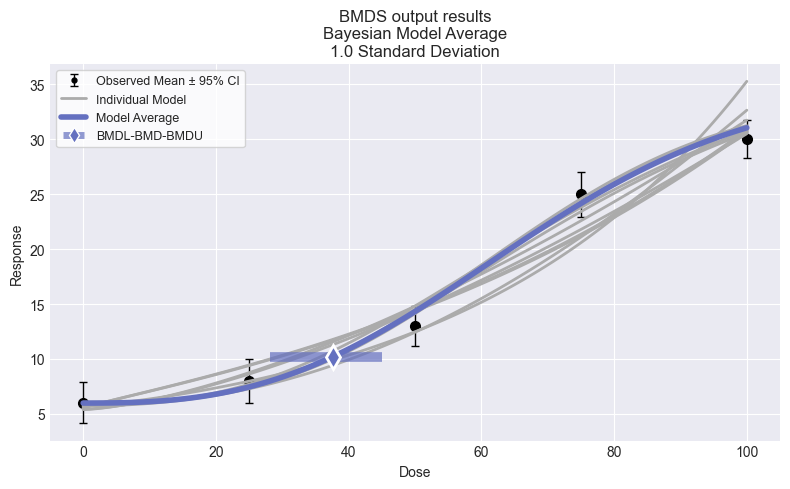

In [2]:
import pybmds

# create a continuous dataset
dataset = pybmds.ContinuousDataset(
    doses=[0, 25, 50, 75, 100],
    ns=[20, 20, 20, 20, 20],
    means=[6, 8, 13, 25, 30],
    stdevs=[4, 4.3, 3.8, 4.4, 3.7],
)

# LOUD model averaging using the standard BMDS continuous suite
session1 = pybmds.Session(dataset=dataset)
session1.add_default_bayesian_models(
    prior_class=pybmds.PriorClass.bayesian_loud,
    model_average=True,      # add model averaging
    include_extended=False,  # standard suite only (not PROAST/EFSA-expanded)
)
session1.execute()

# summarize model-averaged result
res1 = session1.model_average.results
print(f"BMD = {res1.bmd:.2f} [{res1.bmdl:.2f}, {res1.bmdu:.2f}]")

# optional: plot model fits and model-average curve
fig1 = session1.plot(colorize=False)

To print the model average distribution plot and BMD distribution overlay plot:

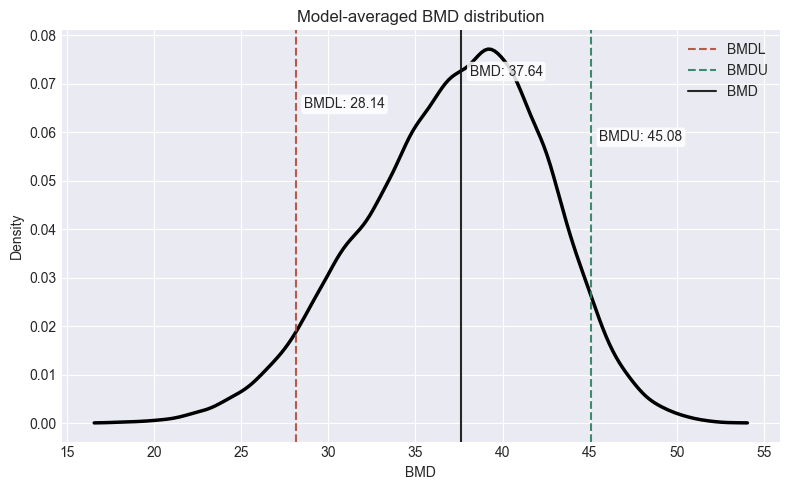

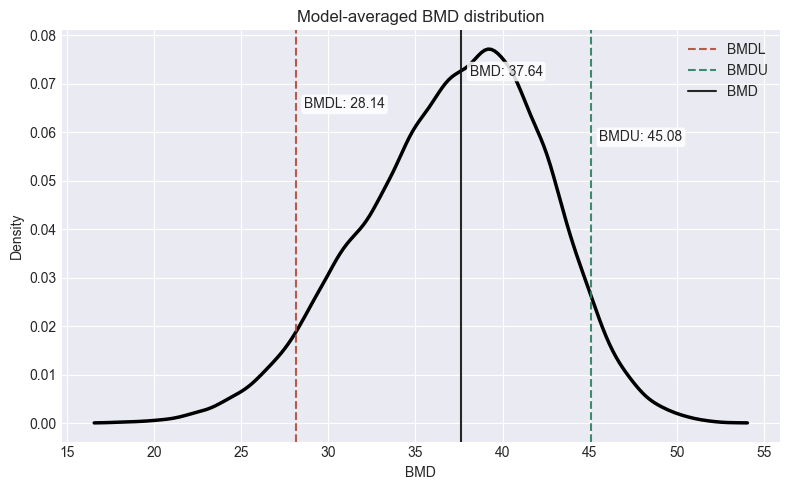

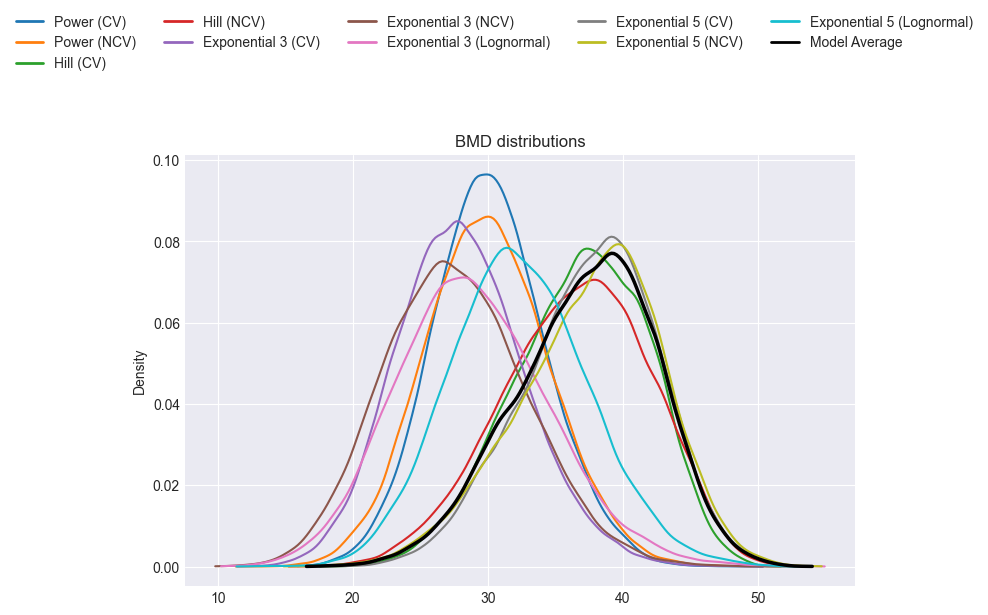

In [12]:
from pybmds.plotting.LOUD import get_model_average_figures
from IPython.display import display

figs = get_model_average_figures(session1, n_chains=1, compressed=True)

# Show only the model-averaged BMD distribution
display(figs["posterior"])


To print the trace plots for an individual model:

Trace plot for: Exponential 5 (CV)


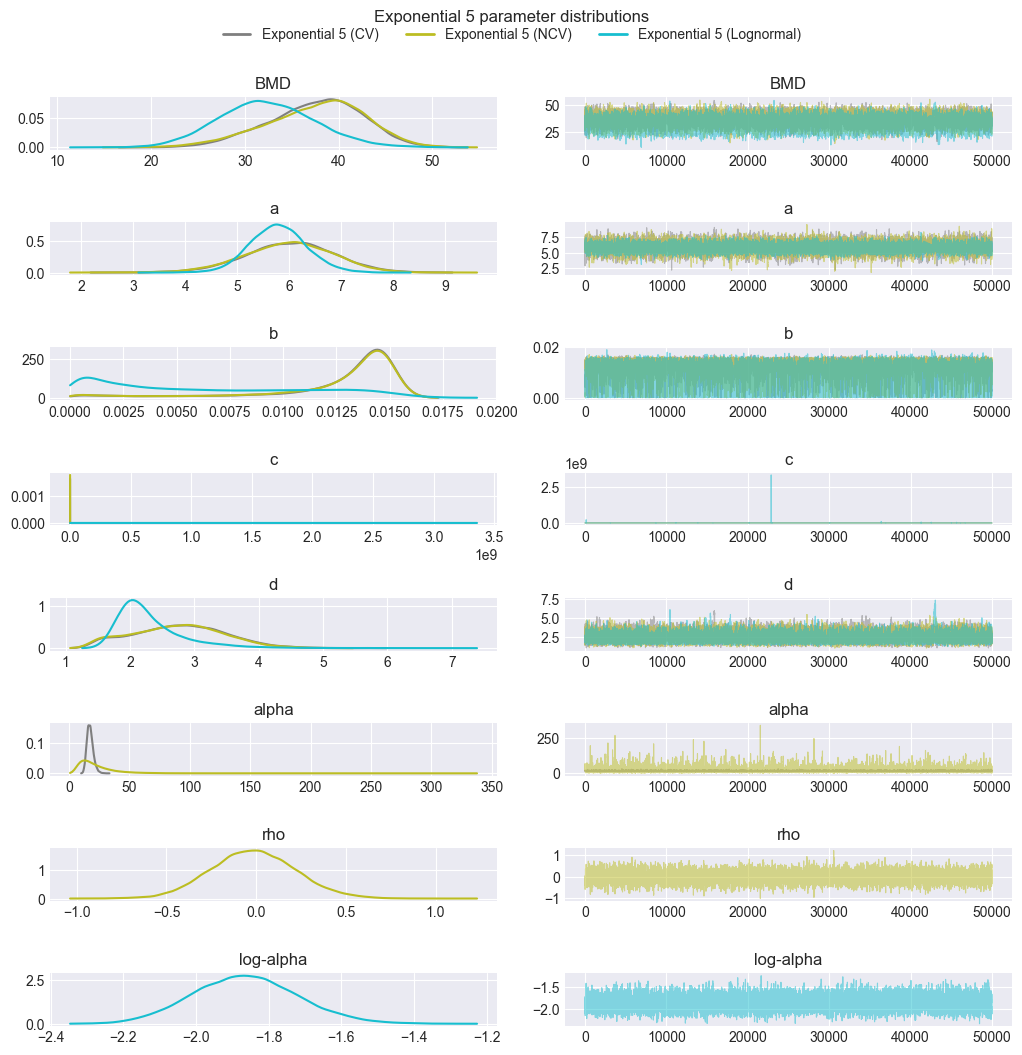

In [23]:
target_model = "Exponential 5 (CV)"

for group in figs["parameter_groups"]:
    if target_model in group["model_names"]:
        print("Trace plot for:", target_model)
        display(group["trace_figure"])
        break

To print out the MCMC summary table for model-specific BMDs:

In [24]:
display(figs["bmd_summary"])

,BMD,Median Absolute Deviation,BMDL,BMDU,R-hat,Markov Chain Standard Error (Median),Bulk Effective Sample Size,Tail Effective Sample Size
model,,,,,,,,
Power (CV),30.057729,2.780242,23.494860,37.290974,NaN,0.050936,7001.496078,9659.981054
Power (NCV),29.865614,3.121942,22.587561,37.741317,NaN,0.063282,5644.584917,8133.388770
Hill (CV),37.180560,3.489951,28.334663,44.444769,NaN,0.113821,1853.176277,2888.504318
Hill (NCV),36.811919,3.811739,27.082097,45.085158,NaN,0.175748,952.079817,809.005793
Exponential 3 (CV),27.844691,3.166942,20.629910,36.143974,NaN,0.055494,6930.085697,9394.813839
Exponential 3 (NCV),27.398044,3.595512,19.246586,36.585955,NaN,0.082357,5386.121028,8668.144564
Exponential 3 (Lognormal),28.648899,3.788625,20.058322,38.634770,NaN,0.071541,6678.092050,8971.741126
Exponential 5 (CV),37.933179,3.371105,28.856224,45.146264,NaN,0.094348,2965.476230,3870.904175
Exponential 5 (NCV),38.103377,3.550649,28.017142,45.518864,NaN,0.099507,2551.950732,3541.573470


To display a summary table of results without MCMC output:

In [26]:
from IPython.display import display

bayes_summary1 = (
session1.to_df(clean=False)
[[
"model_name",
"model_prior",
"model_posterior",
"bmdl",
"bmd",
"bmdu",
"residual_at_lowest_dose",
"residual_of_interest",
]]
.rename(columns={
"model_name": "Model",
"model_prior": "Prior Weights",
"model_posterior": "Posterior Weights",
"bmdl": "BMDL",
"bmd": "BMD",
"bmdu": "BMDU",
"residual_at_lowest_dose": "Residual at Control",
"residual_of_interest": "Scaled Residual",
})
)

df1 = bayes_summary1
display(df1)

,Model,Prior Weights,Posterior Weights,BMDL,BMD,BMDU,Residual at Control,Scaled Residual
0,Power (CV),0.1,0.005547,23.494860,30.057729,37.290974,0.617770,-0.720260
1,Power (NCV),0.1,0.006145,22.587561,29.865614,37.741317,0.624046,-0.724404
2,Hill (CV),0.1,0.165873,28.334663,37.180560,44.444769,-0.038611,0.480381
3,Hill (NCV),0.1,0.094513,27.082097,36.811919,45.085158,0.066068,0.403957
4,Exponential 3 (CV),0.1,0.000110,20.629910,27.844691,36.143974,0.489253,-1.479982
5,Exponential 3 (NCV),0.1,0.000158,19.246586,27.398044,36.585955,0.481474,-1.457518
6,Exponential 3 (Lognormal),0.1,0.000299,20.058322,28.648899,38.634770,-0.252902,-0.792131
7,Exponential 5 (CV),0.1,0.419887,28.856224,37.933179,45.146264,-0.037610,-1.418461
8,Exponential 5 (NCV),0.1,0.301912,28.017142,38.103377,45.518864,-0.006285,-1.443800
9,Exponential 5 (Lognormal),0.1,0.005556,24.158342,32.169295,41.080501,-0.426410,0.247202


### Running Expanded Suite analyses

To run LOUD Bayesian model averaging for continuous data using the expanded suite of models (i.e., BMDS + PROAST + EFSA models):

BMD = 43.09 [31.80, 48.46]


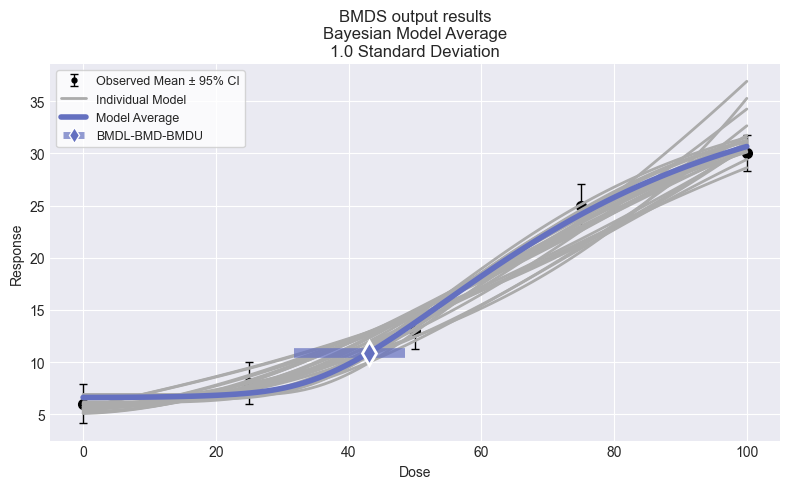

In [25]:
# LOUD model averaging using the expanded BMDS/PROAST/EFSA continuous suite
session2 = pybmds.Session(dataset=dataset)
session2.add_default_bayesian_models(
    prior_class=pybmds.PriorClass.bayesian_loud,
    model_average=True,      # add model averaging
    include_extended=True,  # expanded BMDS/PROAST/EFSA suite  
)
session2.execute()

# summarize model-averaged result
res2 = session2.model_average.results
print(f"BMD = {res2.bmd:.2f} [{res2.bmdl:.2f}, {res2.bmdu:.2f}]")

# optional: plot model fits and model-average curve
fig2 = session2.plot(colorize=False)

And to print out a summary table:

In [27]:
bayes_summary2 = (
session2.to_df(clean=False)
[[
"model_name",
"model_prior",
"model_posterior",
"bmdl",
"bmd",
"bmdu",
"residual_at_lowest_dose",
"residual_of_interest",
]]
.rename(columns={
"model_name": "Model",
"model_prior": "Prior Weights",
"model_posterior": "Posterior Weights",
"bmdl": "BMDL",
"bmd": "BMD",
"bmdu": "BMDU",
"residual_at_lowest_dose": "Residual at Control",
"residual_of_interest": "Scaled Residual",
})
)

df2 = bayes_summary2
display(df2)

,Model,Prior Weights,Posterior Weights,BMDL,BMD,BMDU,Residual at Control,Scaled Residual
0,Power (CV),0.043478,0.000787,23.494860,30.057729,37.290974,0.617770,-0.720260
1,Power (NCV),0.043478,0.000872,22.587561,29.865614,37.741317,0.624046,-0.724404
2,Exponential 3 (CV),0.043478,0.000016,20.629910,27.844691,36.143974,0.489253,-1.479982
3,Exponential 3 (NCV),0.043478,0.000022,19.246586,27.398044,36.585955,0.481474,-1.457518
4,Exponential 3 (Lognormal),0.043478,0.000042,20.058322,28.648899,38.634770,-0.252902,-0.792131
5,Exponential 5 (CV),0.043478,0.059554,28.856224,37.933179,45.146264,-0.037610,-1.418461
6,Exponential 5 (NCV),0.043478,0.042821,28.017142,38.103377,45.518864,-0.006285,-1.443800
7,Exponential 5 (Lognormal),0.043478,0.000788,24.158342,32.169295,41.080501,-0.426410,0.247202
8,Multiplicative Hill (CV),0.043478,0.023526,28.334663,37.180560,44.444769,-0.038611,0.486898
9,Multiplicative Hill (NCV),0.043478,0.013405,27.082097,36.811919,45.085158,0.066132,0.413433


To run LOUD Bayesian model averaging for continuous data using the just the PROAST and EFSA models:

BMD = 43.07 [31.82, 48.44]


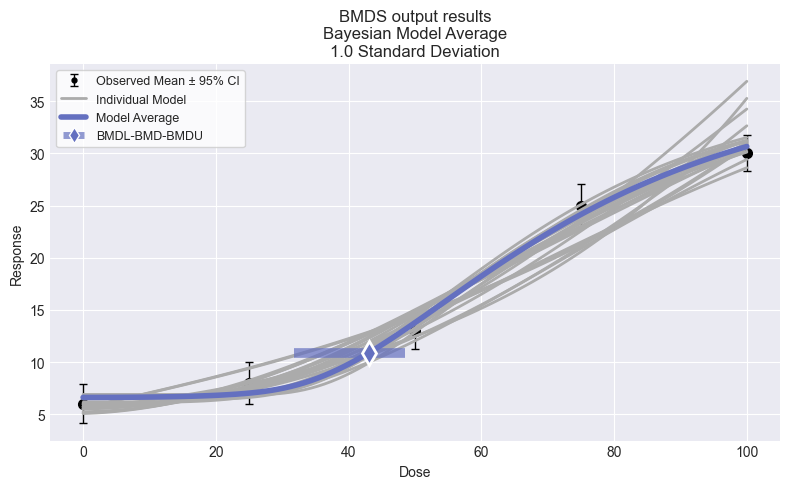

In [28]:
# dataset
dataset = pybmds.ContinuousDataset(
    doses=[0, 25, 50, 75, 100],
    ns=[20, 20, 20, 20, 20],
    means=[6, 8, 13, 25, 30],
    stdevs=[4, 4.3, 3.8, 4.4, 3.7],
)

session3 = pybmds.Session(dataset=dataset)

# Expanded models only (PROAST/EFSA-style set), LOUD priors
expanded_models = [
    pybmds.Models.ExponentialM3,
    pybmds.Models.ExponentialM5,
    pybmds.Models.MultiplicativeHill,
    pybmds.Models.InverseExponential,
    pybmds.Models.Lognormal,
    pybmds.Models.ContinuousGamma,
    pybmds.Models.LMS2,
]

# add all three disttypes (example: constant variance)
dist_types = [
    pybmds.ContinuousDistType.normal,
    pybmds.ContinuousDistType.normal_ncv,
    pybmds.ContinuousDistType.log_normal,
]

for model_name in expanded_models:
    for dt in dist_types:
        session3.add_model(
            model_name,
            settings={
                "priors": pybmds.PriorClass.bayesian_loud,
                "disttype": dt,
            },
        )

session3.add_model_averaging()
session3.execute()

res3 = session3.model_average.results
print(f"BMD = {res3.bmd:.2f} [{res3.bmdl:.2f}, {res3.bmdu:.2f}]")
fig3 = session3.plot(colorize=False)

To print a summary table for the EFSA and PROAST models:

In [29]:
bayes_summary3 = (
session3.to_df(clean=False)
[[
"model_name",
"model_prior",
"model_posterior",
"bmdl",
"bmd",
"bmdu",
"residual_at_lowest_dose",
"residual_of_interest",
]]
.rename(columns={
"model_name": "Model",
"model_prior": "Prior Weights",
"model_posterior": "Posterior Weights",
"bmdl": "BMDL",
"bmd": "BMD",
"bmdu": "BMDU",
"residual_at_lowest_dose": "Residual at Control",
"residual_of_interest": "Scaled Residual",
})
)

df3 = bayes_summary3
display(df3)

,Model,Prior Weights,Posterior Weights,BMDL,BMD,BMDU,Residual at Control,Scaled Residual
0,Exponential 3 (CV),0.047619,0.000016,20.629910,27.844691,36.143974,0.489253,-1.479982
1,Exponential 3 (NCV),0.047619,0.000022,19.246586,27.398044,36.585955,0.481474,-1.457518
2,Exponential 3 (Lognormal),0.047619,0.000042,20.058322,28.648899,38.634770,-0.252902,-0.792131
3,Exponential 5 (CV),0.047619,0.059653,28.856224,37.933179,45.146264,-0.037610,-1.418461
4,Exponential 5 (NCV),0.047619,0.042892,28.017142,38.103377,45.518864,-0.006285,-1.443800
5,Exponential 5 (Lognormal),0.047619,0.000789,24.158342,32.169295,41.080501,-0.426410,0.247202
6,Multiplicative Hill (CV),0.047619,0.023565,28.334663,37.180560,44.444769,-0.038611,0.486898
7,Multiplicative Hill (NCV),0.047619,0.013427,27.082097,36.811919,45.085158,0.066132,0.413433
8,Multiplicative Hill (Lognormal),0.047619,0.000923,23.259407,31.117116,39.292956,-0.431981,0.220687
9,Inverse Exponential (CV),0.047619,0.296165,38.006134,44.411933,48.792456,-0.950892,-0.506609


To compare the model averaged results for all three analyses using different model suites:

In [30]:
import pandas as pd

def ma_point_summary(session, label):
    if session.model_average is None:
        raise ValueError(f"{label} has no model average.")
    r = session.model_average.results
    return {
        "Session": label,
        "BMDL": float(r.bmdl),
        "BMD": float(r.bmd),
        "BMDU": float(r.bmdu),
    }

comparison = pd.DataFrame([
    ma_point_summary(session1, "Session 1 (BMDS only)"),
    ma_point_summary(session2, "Session 2 (BMDS + Expanded)"),
    ma_point_summary(session3, "Session 3 (Expanded only)"),
])

comparison

,Session,BMDL,BMD,BMDU
0,Session 1 (BMDS only),28.137385,37.641983,45.078098
1,Session 2 (BMDS + Expanded),31.796633,43.091885,48.456401
2,Session 3 (Expanded only),31.823005,43.073042,48.443350
